In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "ic" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"


In [1]:
import pandas as pd
import re
import os

In [13]:
df_geral = pd.read_csv(DATA_DIR / 'dados_gerais_bronze1.csv')

In [14]:
df_geral.head()

,Unnamed: 0,user_id,screen_name,name,location,followers_count,created_at,full_text,retweet_count,favorite_count,lang,hashtags,source
0,0,772193576,pauloisfab,paulo rouge,"Sao Paulo, Brazil",439,Sat Oct 01 23:59:59 +0000 2022,se o lula ganhar eu quero uma roda de beijo co...,0,0,pt,[],Twitter for iPhone
1,1,1546155973051662336,jorgehen_pr,quem me conhece sabe 🚩,NaN,27,Sat Oct 01 23:59:59 +0000 2022,@ixslorena LULA PRESIDENTE HOJE,0,0,pt,[],Twitter for Android
2,2,1515570566736003072,aanandaaluz,Ananda,pqp,14,Sat Oct 01 23:59:59 +0000 2022,mãe morrendo de alegria na carreata do Lula,0,3,pt,[],Twitter for Android
3,3,1449859889589899264,lyeroses,sasa៹ 13 ⭐🚩,only blink,4973,Sat Oct 01 23:59:59 +0000 2022,@trajaza AVISA QUE MEU PAI LULA VAI GANHAR PRI...,0,3,pt,[],Twitter for Android
4,4,1304397938131599361,HIGH_G_LUIZ,łu¡z 🪐,IZ*ONE,422,Sat Oct 01 23:59:59 +0000 2022,@indieoffw O RJ elegendo castro e juram que va...,0,0,pt,[],Twitter for Android


In [16]:
df_texto = pd.read_parquet(DATA_DIR / 'tweets_base_normalizados.parquet')

In [19]:
df_texto.head()

,full_text,clean_text
0,se o lula ganhar eu quero uma roda de beijo co...,se o lula ganhar eu quero uma roda de beijo co...
1,@ixslorena LULA PRESIDENTE HOJE,@USER LULA PRESIDENTE HOJE
2,mãe morrendo de alegria na carreata do Lula,mãe morrendo de alegria na carreata do Lula
3,@trajaza AVISA QUE MEU PAI LULA VAI GANHAR PRI...,@USER AVISA QUE MEU PAI LULA VAI GANHAR PRIMEI...
4,@indieoffw O RJ elegendo castro e juram que va...,@USER O RJ elegendo castro e juram que vai dar...


Tweets by exact created_at:


created_at
2022-10-01 13:31:16-03:00    1
2022-10-01 13:31:22-03:00    1
2022-10-01 13:31:34-03:00    1
2022-10-01 13:31:35-03:00    2
2022-10-01 13:31:38-03:00    1
2022-10-01 13:31:39-03:00    1
2022-10-01 13:31:41-03:00    1
2022-10-01 13:31:42-03:00    2
2022-10-01 13:31:43-03:00    1
2022-10-01 13:31:44-03:00    1
2022-10-01 13:31:49-03:00    1
2022-10-01 13:31:53-03:00    1
2022-10-01 13:31:55-03:00    2
2022-10-01 13:31:58-03:00    2
2022-10-01 13:32:00-03:00    1
2022-10-01 13:32:01-03:00    2
2022-10-01 13:32:03-03:00    2
2022-10-01 13:32:04-03:00    1
2022-10-01 13:32:10-03:00    1
2022-10-01 13:32:13-03:00    2
Name: count, dtype: int64

Tweets by day, hour and minute:


,day,hour,minute,tweet_count
0,2022-10-01,13,31,18
1,2022-10-01,13,32,37
2,2022-10-01,13,33,29
3,2022-10-01,13,34,32
4,2022-10-01,13,35,58
...,...,...,...,...
444,2022-10-01,20,55,656
445,2022-10-01,20,56,668
446,2022-10-01,20,57,680
447,2022-10-01,20,58,718


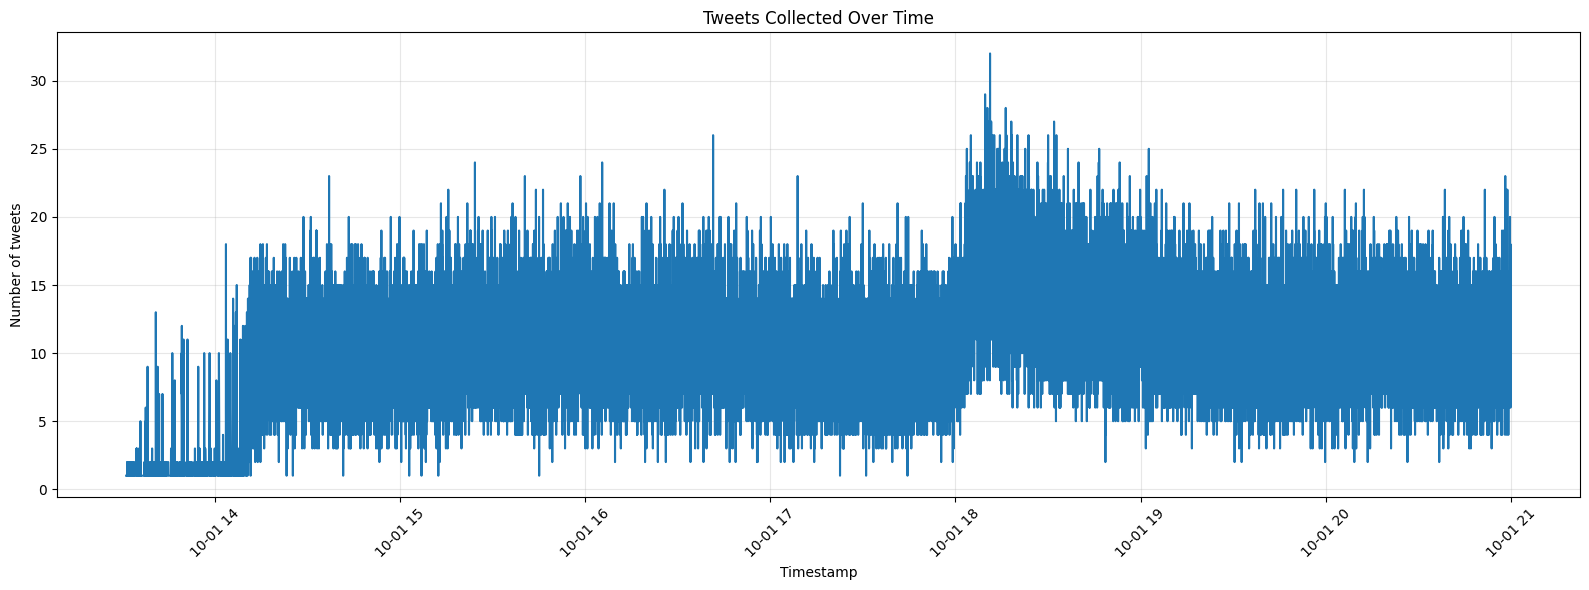

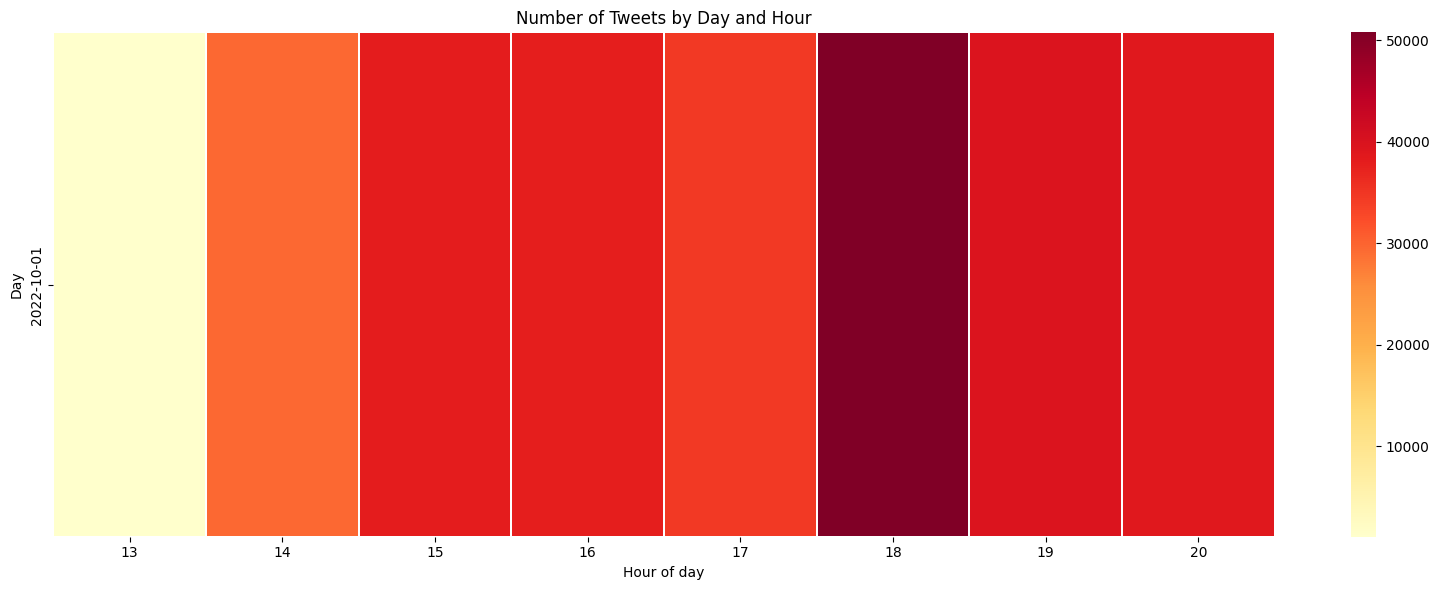

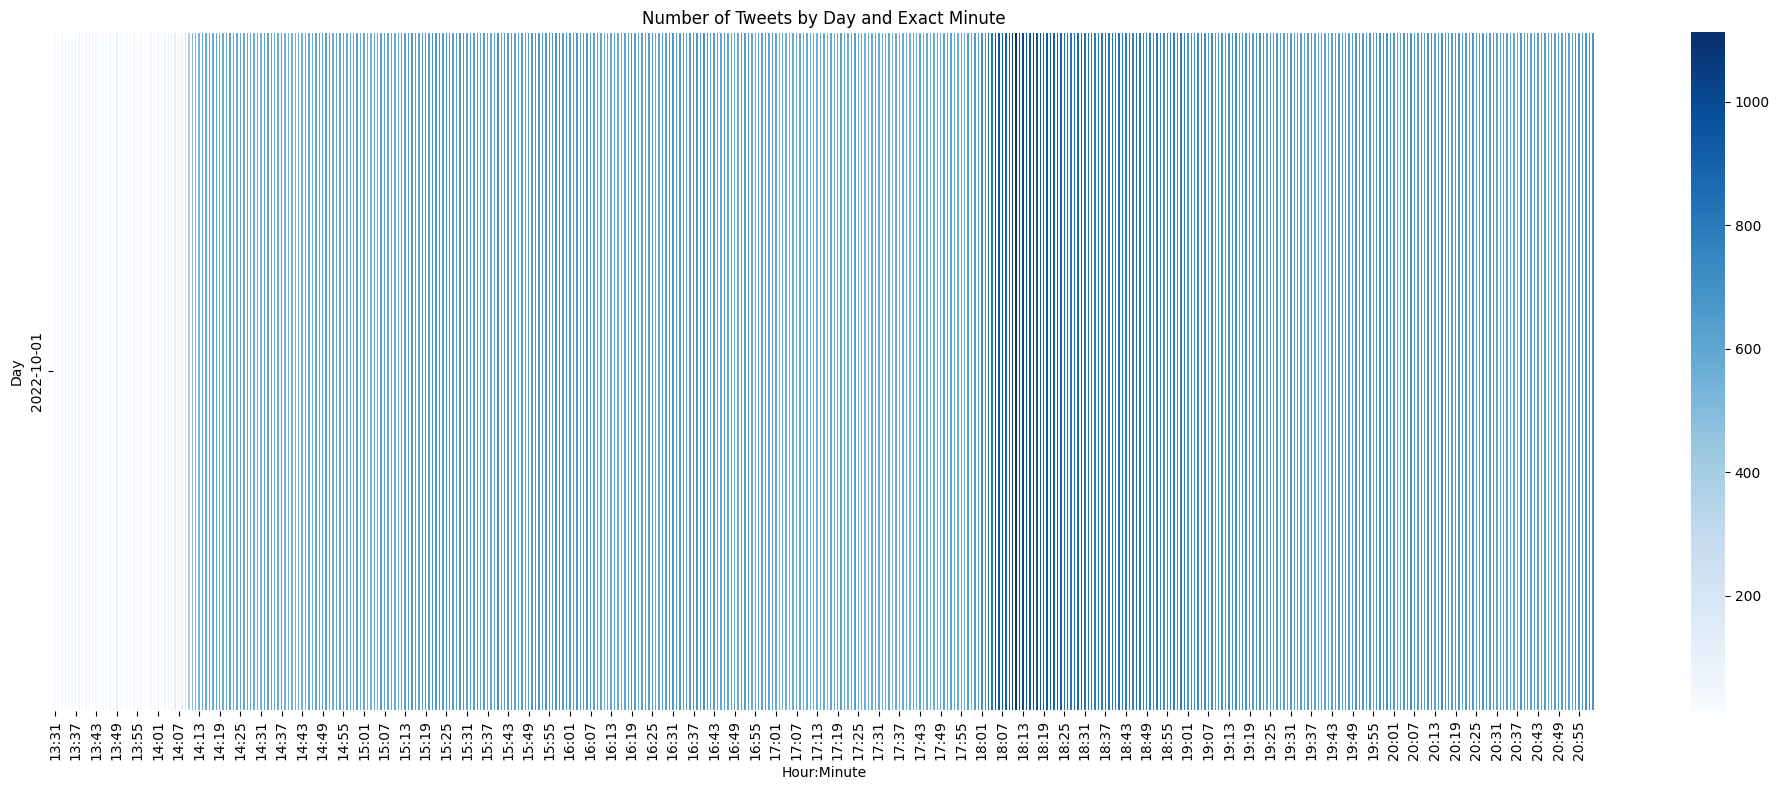

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Twitter's created_at string into datetime
df_tempo = df_geral[["created_at"]].copy()
df_tempo["created_at"] = pd.to_datetime(
    df_tempo["created_at"],
    format="%a %b %d %H:%M:%S %z %Y",
    errors="coerce"
)

# If you want to inspect in Brazil time instead of UTC, uncomment the next line
df_tempo["created_at"] = df_tempo["created_at"].dt.tz_convert("America/Sao_Paulo")

df_tempo = df_tempo.dropna(subset=["created_at"])

# Create columns for day, hour and minute
df_tempo["day"] = df_tempo["created_at"].dt.date
df_tempo["hour"] = df_tempo["created_at"].dt.hour
df_tempo["minute"] = df_tempo["created_at"].dt.minute
df_tempo["hour_minute"] = df_tempo["created_at"].dt.strftime("%H:%M")

# 1) Count tweets by exact timestamp
exact_time_counts = (
    df_tempo["created_at"]
    .value_counts()
    .sort_index()
)

print("Tweets by exact created_at:")
display(exact_time_counts.head(20))

# 2) Count tweets by hour and minute of each day
day_hour_minute_counts = (
    df_tempo.groupby(["day", "hour", "minute"])
    .size()
    .reset_index(name="tweet_count")
    .sort_values(["day", "hour", "minute"])
)

print("Tweets by day, hour and minute:")
display(day_hour_minute_counts.head(700))

# 3) Plot timeline of exact collection times
plt.figure(figsize=(16, 6))
plt.plot(exact_time_counts.index, exact_time_counts.values, color="tab:blue")
plt.title("Tweets Collected Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Number of tweets")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Heatmap: day x hour
heatmap_hour = (
    df_tempo.groupby(["day", "hour"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_hour, cmap="YlOrRd", linewidths=0.2)
plt.title("Number of Tweets by Day and Hour")
plt.xlabel("Hour of day")
plt.ylabel("Day")
plt.tight_layout()
plt.show()

# 5) Heatmap: day x exact minute (HH:MM)
heatmap_minute = (
    df_tempo.groupby(["day", "hour_minute"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_minute, cmap="Blues", linewidths=0.1)
plt.title("Number of Tweets by Day and Exact Minute")
plt.xlabel("Hour:Minute")
plt.ylabel("Day")
plt.tight_layout()
plt.show()
